# Exploring PDSCH DM-RS Configurations

This notebook demonstrates how different PDSCH Demodulation Reference Signal (DM-RS) configurations affect resource-element allocation.

Starting from a simple PDSCH configuration, the notebook progressively explores several DM-RS options, including:

- DM-RS Configuration Types 1 and 2
- Single-symbol and double-symbol DM-RS
- Additional DM-RS symbol positions (`additionalPos`)
- Different Type-A starting positions (`typeA1stPos`)
- Mapping Type A and Mapping Type B transmissions

For each configuration, a PDSCH resource grid is created and visualized so that the placement of DM-RS resource elements can be examined directly. By comparing these allocation maps, you can see how DM-RS density, symbol locations, and frequency-domain patterns change with different parameter settings.

The examples provide a practical way to understand how NeoRadium implements the DM-RS configurations defined by the 5G NR standard and how those configurations influence the resources available for PDSCH data transmission.

In [1]:
import numpy as np
import scipy.io

from neoradium import BandwidthPart, PDSCH


In [2]:
# Create a bandwidth part with 5 resource blocks and 30 kHz subcarrier spacing
bwp = BandwidthPart(numRbs=5, spacing=30)
bwp.print()


Bandwidth Part Properties:
  Resource Blocks:    5 RBs starting at 0 (60 subcarriers)
  Subcarrier Spacing: 30 kHz
  CP Type:            normal
  Interleaving:       No
  Bandwidth:          1.8 MHz
  symbolsPerSlot:     14
  slotsPerSubFrame:   2
  nFFT:               1024
  frameNo:            0
  slotNo:             0




PDSCH Properties:
  mappingType:               A
  nID:                       1
  rnti:                      1
  numLayers:                 2
  numCodewords:              1
  modulation:                16QAM
  PRG Size:                  Wideband
  portSet:                   0   1  
  symSet:                    0   1   2   3   4   5   6   7   8   9   10  11  12  13 
  prbSet:                    0   1   2   3   4  
  DMRS:
    configType:              1
    nIDs:                    []
    scID:                    0
    sameSeq:                 True
    symbols:                 Single
    typeA1stPos:             2
    additionalPos:           0
    cdmGroups (port:cdm):    0:0  1:0 
    deltaShifts (port:cdm):  0:0  1:0 
    numCdmGroupsWithoutData: 1
    symSet:                  2
    REs (before shift):      0 2 4 6 8 10
    epreRatioDb:             0 (dB)

Number of resource elements:
  GridSize:       1680
  PDSCH:          1620
  DMRS:           60


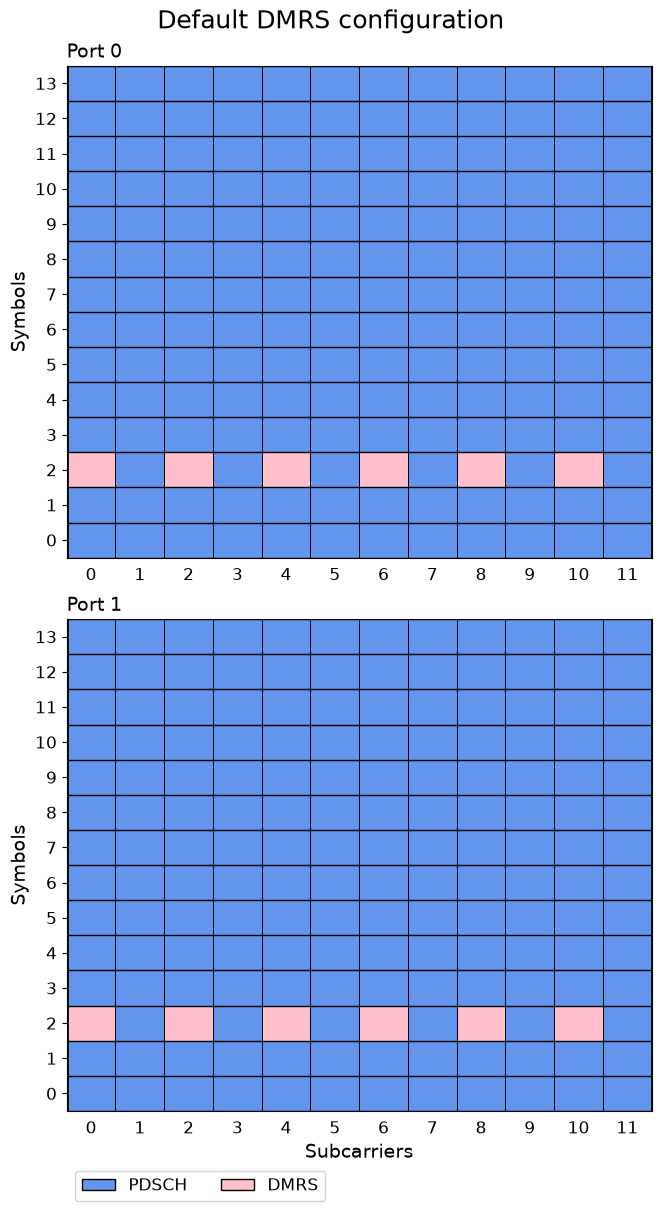

In [3]:
# Create a 2-layer PDSCH with mapping type A (default) using all OFDM symbols and all PRBs in the BWP
pdsch = PDSCH(bwp, numLayers=2)
pdsch.setDMRS()     # Default DM-RS Configuration

pdsch.print()

# Initialize the resource grid of the PDSCH object. This creates an internal Grid object and 
# populates it with the DM-RS values
pdsch.initGrid()

# Print some statistics about the PDSCH resource grid
print("Number of resource elements:")
stats = pdsch.grid.getStats() 
for key, value in stats.items(): print("  %-15s %d"%(key+":", value))

# Draw grid map for both layers
pdsch.grid.drawMap(pdsch.portSet, title="Default DMRS configuration");

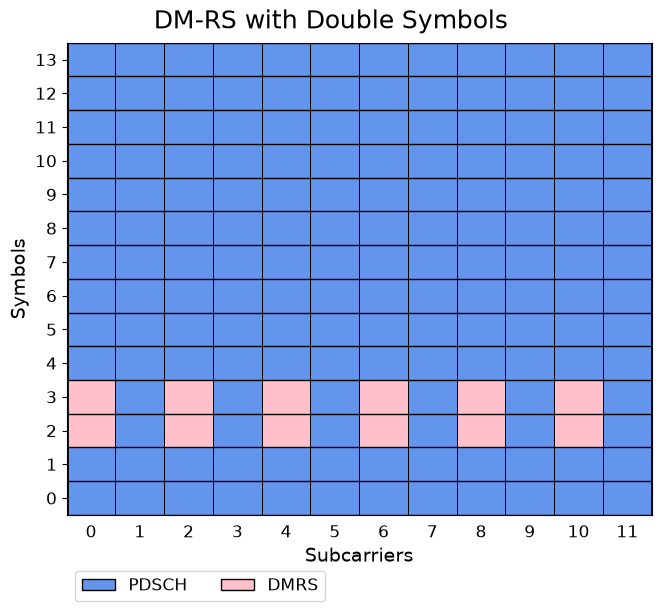

In [4]:
# Let's see an example of DM-RS with double symbols (symbols=2) - (shown for one layer only)
pdsch.setDMRS(symbols=2)

# Reinitialize the PDSCH resource grid because the DM-RS configuration has changed
pdsch.initGrid()

# Draw grid map for first layer
pdsch.grid.drawMap(title="DM-RS with Double Symbols");    


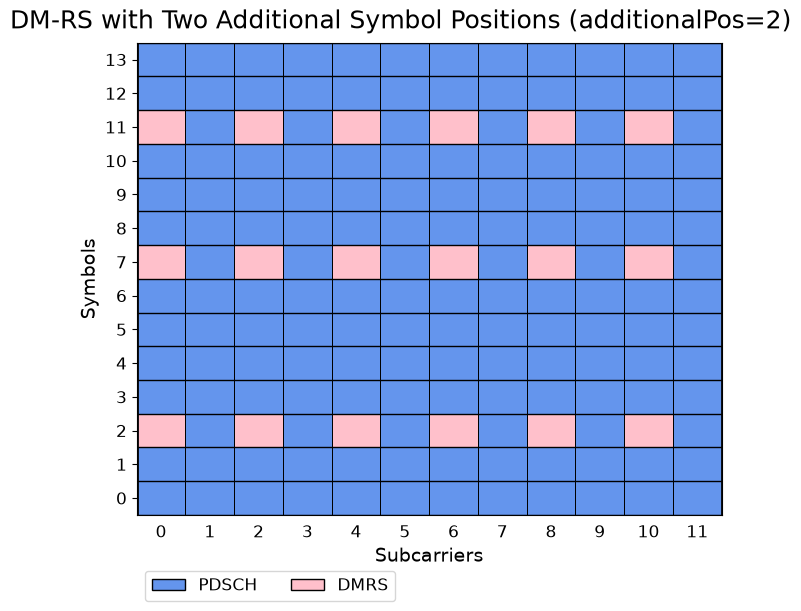

In [5]:
# Use two additional symbol positions for DM-RS (additionalPos=2)
pdsch.setDMRS(additionalPos=2)  # Using setDMRS 
pdsch.initGrid()

# Draw grid map for first layer
pdsch.grid.drawMap(title="DM-RS with Two Additional Symbol Positions (additionalPos=2)");


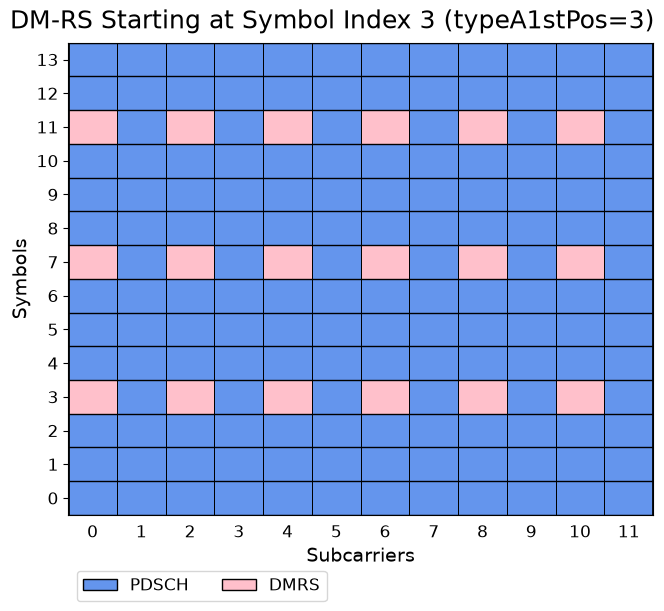

In [6]:
# Same as above but starting at the third position (typeA1stPos=3)
# Note that this works only for PDSCH with Mapping Type A
pdsch.setDMRS(additionalPos=2, typeA1stPos=3)
pdsch.initGrid()
pdsch.grid.drawMap(title="DM-RS Starting at Symbol Index 3 (typeA1stPos=3)");


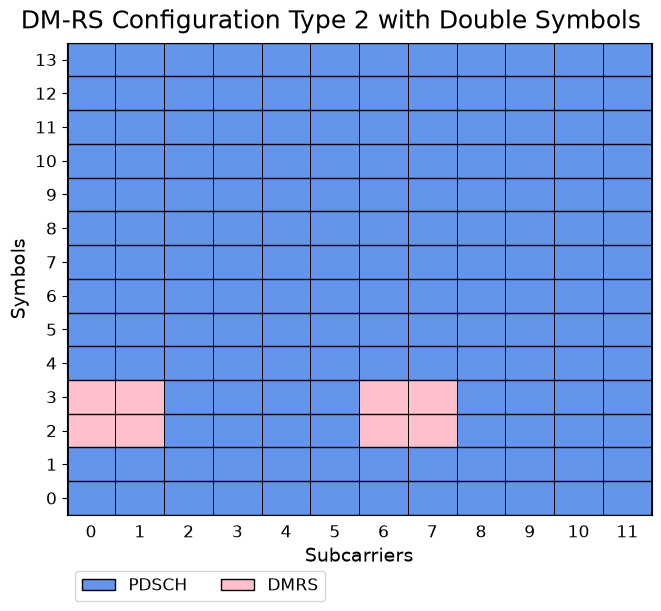

In [7]:
# Now let's see an example of DM-RS configuration type 2 and double DMRS symbols (symbols=2)
pdsch.setDMRS(configType=2, symbols=2)
pdsch.initGrid()
pdsch.grid.drawMap(title="DM-RS Configuration Type 2 with Double Symbols");


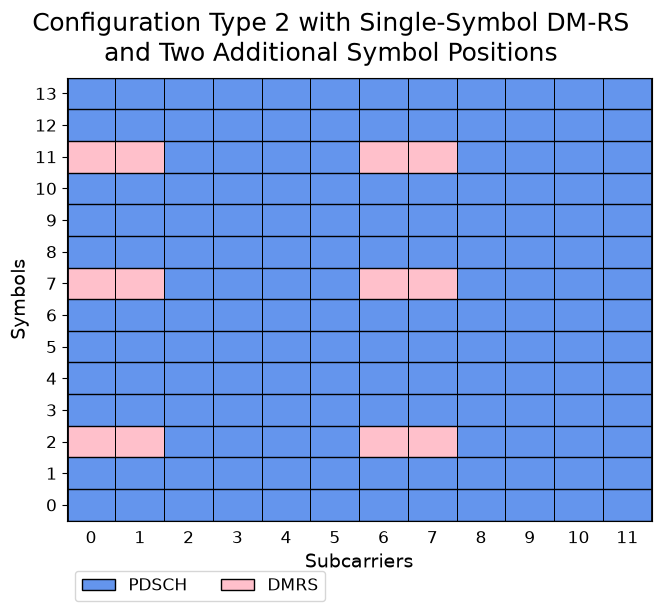

In [8]:
# Using 2 additional symbol positions for DMRS (additionalPos=2)
pdsch.setDMRS(configType=2, additionalPos=2)
pdsch.initGrid()
pdsch.grid.drawMap(title="Configuration Type 2 with Single-Symbol DM-RS\nand Two Additional Symbol Positions");


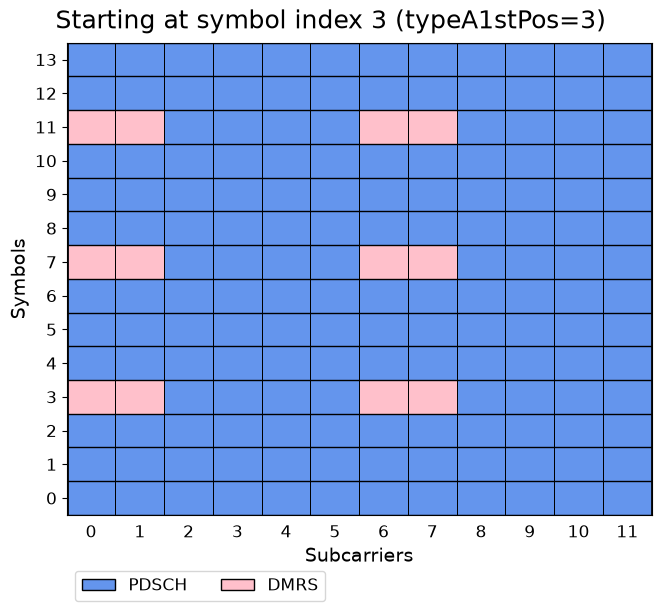

In [9]:
# Same as above, but starting at the third position (typeA1stPos=3)
# Note that this works only for PDSCH with Mapping Type A
pdsch.setDMRS(configType=2, additionalPos=2, typeA1stPos=3)
pdsch.initGrid()
pdsch.grid.drawMap(title="Starting at symbol index 3 (typeA1stPos=3)");



PDSCH Properties:
  mappingType:               B
  nID:                       1
  rnti:                      1
  numLayers:                 2
  numCodewords:              1
  modulation:                16QAM
  PRG Size:                  Wideband
  portSet:                   0   1  
  symSet:                    1   2   3   4   5   6   7   8   9  
  prbSet:                    0   1   2   3   4  
  DMRS:
    configType:              1
    nIDs:                    []
    scID:                    0
    sameSeq:                 True
    symbols:                 Double
    typeA1stPos:             2
    additionalPos:           1
    cdmGroups (port:cdm):    0:0  1:0 
    deltaShifts (port:cdm):  0:0  1:0 
    numCdmGroupsWithoutData: 1
    symSet:                  1   2   6   7
    REs (before shift):      0 2 4 6 8 10
    epreRatioDb:             0 (dB)



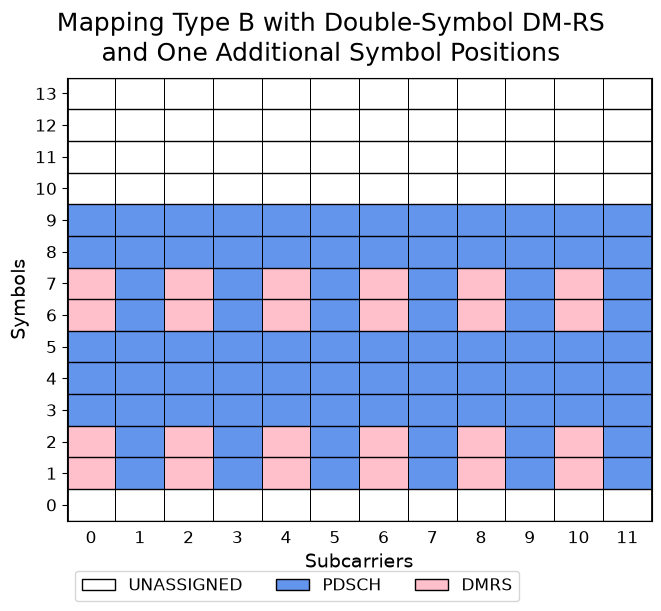

In [10]:
# Now using a PDSCH with mapping type B (DM-RS symbols are relative to PDSCH start symbol)
# This PDSCH uses OFDM symbols 1 through 9.
pdsch = PDSCH(bwp, mappingType='B', numLayers=2, symStart=1, symLen=9)

# Default DM-RS settings with one additional symbol position and double symbols
pdsch.setDMRS(additionalPos=1, symbols=2) 
pdsch.initGrid()
pdsch.print()
pdsch.grid.drawMap(title="Mapping Type B with Double-Symbol DM-RS\nand One Additional Symbol Positions");


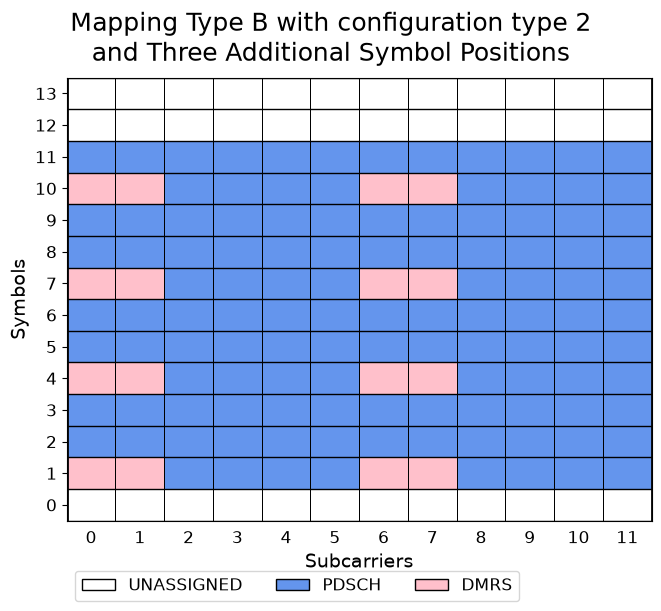

In [11]:
# Use a PDSCH with mapping type B over OFDM symbols 1 through 11.
pdsch = PDSCH(bwp, mappingType='B', numLayers=2, symStart=1, symLen=11)

# Now using configuration type 2 with 3 additional symbol positions
pdsch.setDMRS(configType=2, additionalPos=3)
pdsch.initGrid()
pdsch.grid.drawMap(title="Mapping Type B with configuration type 2\nand Three Additional Symbol Positions");
